# EDA — dunnhumby The Complete Journey

This notebook performs an exploratory data analysis of the **dunnhumby The Complete Journey** dataset.

## Research-oriented goals

The EDA is organized around the research direction:

> **Machine Learning-Based Customer–Category Promotion Dependency Analysis for Personalized Coupon Targeting in Grocery Retail**

The notebook therefore does more than basic descriptive statistics. It explores:

- dataset structure and data quality;
- household/customer purchasing behavior;
- basket and product/category behavior;
- sales, quantity, and discount distributions;
- the three discount fields separately:
  - `retail_disc`
  - `coupon_disc`
  - `coupon_match_disc`
- campaign, coupon, and coupon-redemption behavior;
- mailer/display promotional exposure;
- customer × category behavior over time;
- preliminary treatment/outcome patterns relevant to later Causal ML.

> **Important:** The notebook does **not** claim causal effects. EDA only describes observed patterns and relationships. The Complete Journey is observational data, so causal identification requires additional assumptions and a separate causal-inference stage.


## 1. Dataset tables

According to the supplied User Guide, the main tables are:

| Table | Main purpose |
|---|---|
| `transaction_data` | Product-level purchase lines |
| `product` | Product/category hierarchy and brand information |
| `hh_demographic` | Demographic segmentation for a portion of households |
| `campaign_table` | Campaigns received by households |
| `campaign_desc` | Campaign start/end days and campaign type |
| `coupon` | Coupons and the products for which they are redeemable |
| `coupon_redempt` | Coupons actually redeemed by households |
| `causal_data` | Weekly product/store mailer and in-store display information |

### Expected `transaction_data` columns

`household_key`, `basket_id`, `day`, `product_id`, `quantity`, `sales_value`, `store_id`, `coupon_match_disc`, `coupon_disc`, `retail_disc`, `trans_time`, `week_no`.

The User Guide states that `transaction_data` contains all products purchased by households and that each line is essentially equivalent to a line on a store receipt.


In [1]:
# 2. Imports and display configuration

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

print("Python / pandas environment ready.")


Python / pandas environment ready.


In [2]:
# 3. Locate dataset files
#
# Put the Complete Journey CSV files in one of these locations:
#   ./data/
#   ./dataset/
#   ./The Complete Journey/
#   or change DATA_DIR manually below.
#
# The notebook also recursively searches the current working directory.

from pathlib import Path

SEARCH_ROOTS = [
    Path("./data"),
    Path("./dataset"),
    Path("./The Complete Journey"),
    Path("."),
]

csv_paths = []
seen = set()

for root in SEARCH_ROOTS:
    if root.exists():
        for p in root.rglob("*.csv"):
            rp = p.resolve()
            if rp not in seen:
                csv_paths.append(p)
                seen.add(rp)

csv_paths = sorted(csv_paths)

print(f"CSV files found: {len(csv_paths)}")
for p in csv_paths:
    print(" -", p)


CSV files found: 8
 - data/campaign_desc.csv
 - data/campaign_table.csv
 - data/causal_data.csv
 - data/coupon.csv
 - data/coupon_redempt.csv
 - data/hh_demographic.csv
 - data/product.csv
 - data/transaction_data.csv


### If no CSV files are found

The notebook file is intentionally data-location independent because the supplied User Guide is documentation rather than the transaction CSVs themselves.

Place the dataset CSVs under `./data/`, for example:

```text
project/
├── dunnhumby_complete_journey_eda.ipynb
└── data/
    ├── transaction_data.csv
    ├── product.csv
    ├── campaign_table.csv
    ├── campaign_desc.csv
    ├── coupon.csv
    ├── coupon_redempt.csv
    ├── causal_data.csv
    └── hh_demographic.csv
```

The next cell attempts to identify tables by filename.


In [3]:
# 4. Load available tables

def normalize_name(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(".csv", "")
    )

TABLE_ALIASES = {
    "transaction_data": ["transaction_data", "transaction"],
    "product": ["product"],
    "hh_demographic": ["hh_demographic", "demographic"],
    "campaign_table": ["campaign_table"],
    "campaign_desc": ["campaign_desc"],
    "coupon": ["coupon"],
    "coupon_redempt": ["coupon_redempt", "coupon_redemption"],
    "causal_data": ["causal_data"],
}

tables = {}

for p in csv_paths:
    stem = normalize_name(p.name)
    matched = None
    for table_name, aliases in TABLE_ALIASES.items():
        if any(stem == a or stem.startswith(a + "_") for a in aliases):
            matched = table_name
            break

    if matched:
        try:
            df = pd.read_csv(p)
            tables[matched] = df
            print(f"{matched:20s} {df.shape} <- {p}")
        except Exception as e:
            print(f"Could not read {p}: {e}")

print("\nLoaded tables:", list(tables.keys()))


campaign_desc        (30, 4) <- data/campaign_desc.csv
campaign_table       (7208, 3) <- data/campaign_table.csv
causal_data          (36786524, 5) <- data/causal_data.csv
coupon               (124548, 3) <- data/coupon.csv
coupon               (2318, 4) <- data/coupon_redempt.csv
hh_demographic       (801, 8) <- data/hh_demographic.csv
product              (92353, 7) <- data/product.csv
transaction_data     (2595732, 12) <- data/transaction_data.csv

Loaded tables: ['campaign_desc', 'campaign_table', 'causal_data', 'coupon', 'hh_demographic', 'product', 'transaction_data']


In [4]:
# 5. Basic schema inspection

for name, df in tables.items():
    print("=" * 90)
    print(name, df.shape)
    display(df.head(5))
    print("\nDtypes:")
    display(df.dtypes.to_frame("dtype"))


campaign_desc (30, 4)


,DESCRIPTION,CAMPAIGN,START_DAY,END_DAY
0,TypeB,24,659,719
1,TypeC,15,547,708
2,TypeB,25,659,691
3,TypeC,20,615,685
4,TypeB,23,646,684



Dtypes:


,dtype
DESCRIPTION,object
CAMPAIGN,int64
START_DAY,int64
END_DAY,int64


campaign_table (7208, 3)


...

,dtype
PRODUCT_ID,int64
MANUFACTURER,int64
DEPARTMENT,object
BRAND,object
COMMODITY_DESC,object
SUB_COMMODITY_DESC,object
CURR_SIZE_OF_PRODUCT,object


transaction_data (2595732, 12)


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.390,364,-0.600,1631,1,0.000,0.000
1,2375,26984851472,1,1033142,1,0.820,364,0.000,1631,1,0.000,0.000
2,2375,26984851472,1,1036325,1,0.990,364,-0.300,1631,1,0.000,0.000
3,2375,26984851472,1,1082185,1,1.210,364,0.000,1631,1,0.000,0.000
4,2375,26984851472,1,8160430,1,1.500,364,-0.390,1631,1,0.000,0.000



Dtypes:


,dtype
household_key,int64
BASKET_ID,int64
DAY,int64
PRODUCT_ID,int64
QUANTITY,int64
SALES_VALUE,float64
STORE_ID,int64
RETAIL_DISC,float64
TRANS_TIME,int64
WEEK_NO,int64


In [5]:
# 6. Missing values and duplicate rows

quality_rows = []

for name, df in tables.items():
    quality_rows.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "duplicate_rows": int(df.duplicated().sum()),
        "missing_cells": int(df.isna().sum().sum()),
        "missing_pct": float(df.isna().mean().mean() * 100),
    })

quality = pd.DataFrame(quality_rows).sort_values("missing_pct", ascending=False)
display(quality)

for name, df in tables.items():
    miss = (
        df.isna().mean()
        .mul(100)
        .sort_values(ascending=False)
        .rename("missing_pct")
        .to_frame()
    )
    miss = miss[miss["missing_pct"] > 0]
    if len(miss):
        print(f"\n{name}:")
        display(miss)


,table,rows,columns,duplicate_rows,missing_cells,missing_pct
0,campaign_desc,30,4,0,0,0.000
1,campaign_table,7208,3,0,0,0.000
2,causal_data,36786524,5,0,0,0.000
3,coupon,2318,4,0,0,0.000
4,hh_demographic,801,8,0,0,0.000
5,product,92353,7,0,0,0.000
6,transaction_data,2595732,12,0,0,0.000


## 2. Transaction-level EDA

`transaction_data` is the central behavioral table. A row represents a product line within a purchase occasion/basket, not necessarily an entire shopping trip.

The analysis below keeps the three discount variables separate rather than immediately combining them.


In [13]:
# 7. Transaction table setup

tx = tables.get("transaction_data")

if tx is None:
    print("transaction_data was not found. Add the CSV files and rerun this section.")
else:
    # Standardize column names
    tx.columns = (
        tx.columns
        .astype(str)
        .str.strip()
        .str.lower()
    )
    expected = [
        "household_key", "basket_id", "day", "product_id", "quantity",
        "sales_value", "store_id", "coupon_match_disc", "coupon_disc",
        "retail_disc", "trans_time", "week_no"
    ]
    missing_cols = [c for c in expected if c not in tx.columns]
    print("Missing expected columns:", missing_cols)

    numeric_candidates = [
        "household_key", "basket_id", "day", "product_id", "quantity",
        "sales_value", "store_id", "coupon_match_disc", "coupon_disc",
        "retail_disc", "trans_time", "week_no"
    ]

    for c in numeric_candidates:
        if c in tx.columns:
            tx[c] = pd.to_numeric(tx[c], errors="coerce")

    display(tx.describe(include="all").T)


Missing expected columns: []


,count,mean,std,min,25%,50%,75%,max
household_key,"2,595,732.000","1,271.953",726.066,1.000,656.000,"1,272.000","1,913.000","2,500.000"
basket_id,"2,595,732.000","34,026,199,138.887","4,711,649,037.863","26,984,851,472.000","30,408,046,256.000","32,760,806,548.000","40,126,853,628.000","42,305,362,535.000"
day,"2,595,732.000",388.756,189.721,1.000,229.000,390.000,553.000,711.000
product_id,"2,595,732.000","2,891,435.160","3,837,403.689","25,671.000","917,459.000","1,028,816.000","1,133,018.000","18,316,298.000"
quantity,"2,595,732.000",100.429,"1,153.436",0.000,1.000,1.000,1.000,"89,638.000"
sales_value,"2,595,732.000",3.104,4.182,0.000,1.290,2.000,3.490,840.000
store_id,"2,595,732.000","3,142.673","8,937.113",1.000,330.000,372.000,422.000,"34,280.000"
retail_disc,"2,595,732.000",-0.539,1.249,-180.000,-0.690,-0.010,0.000,3.990
trans_time,"2,595,732.000","1,561.586",399.838,0.000,"1,308.000","1,613.000","1,843.000","2,359.000"
week_no,"2,595,732.000",56.221,27.102,1.000,33.000,56.000,80.000,102.000


In [14]:
print(tx.columns.tolist())
print("\nShape:", tx.shape)

['household_key', 'basket_id', 'day', 'product_id', 'quantity', 'sales_value', 'store_id', 'retail_disc', 'trans_time', 'week_no', 'coupon_disc', 'coupon_match_disc']

Shape: (2595732, 12)


In [23]:
# 8. Core transaction statistics

if tx is not None:
    n_households = tx["household_key"].nunique()
    n_baskets = tx["basket_id"].nunique()
    n_products = tx["product_id"].nunique()
    n_stores = tx["store_id"].nunique()
    n_weeks = tx["week_no"].nunique()

    summary = pd.Series({
        "transaction_rows": len(tx),
        "unique_households": n_households,
        "unique_baskets": n_baskets,
        "unique_products": n_products,
        "unique_stores": n_stores,
        "unique_weeks": n_weeks,
        "total_quantity": tx["quantity"].sum(),
        "total_sales_value": tx["sales_value"].sum(),
    })

    display(summary.to_frame("value"))


,value
transaction_rows,"2,595,732.000"
unique_households,"2,500.000"
unique_baskets,"276,484.000"
unique_products,"92,339.000"
unique_stores,582.000
unique_weeks,102.000
total_quantity,"260,685,622.000"
total_sales_value,"8,057,463.080"


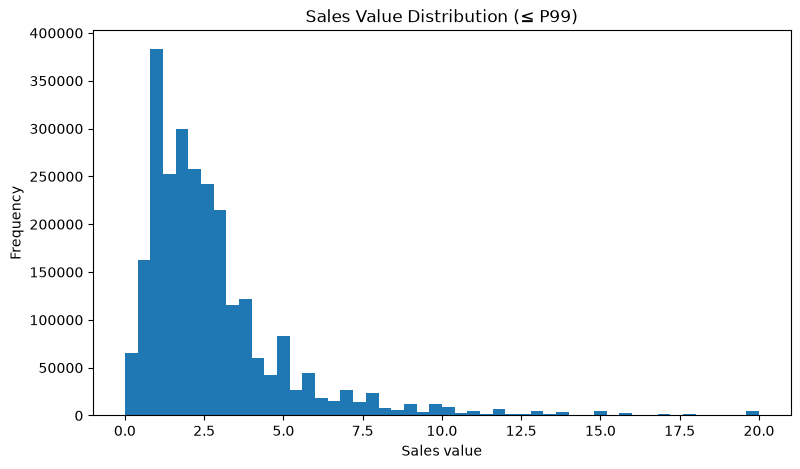

In [ ]:
# tx["quantity"].dropna()
# tx["sales_value"].dropna().nunique()
fig, ax = plt.subplots(figsize=(9, 5))
sales = tx["sales_value"].dropna()
upper = sales.quantile(0.99)
ax.hist(
    sales[sales <= upper],
    bins=50
)
ax.set_title("Distribution of Sales Value per Transaction Line (≤ 99th percentile)")
ax.set_xlabel("Sales value")
ax.set_ylabel("Frequency")
plt.show()

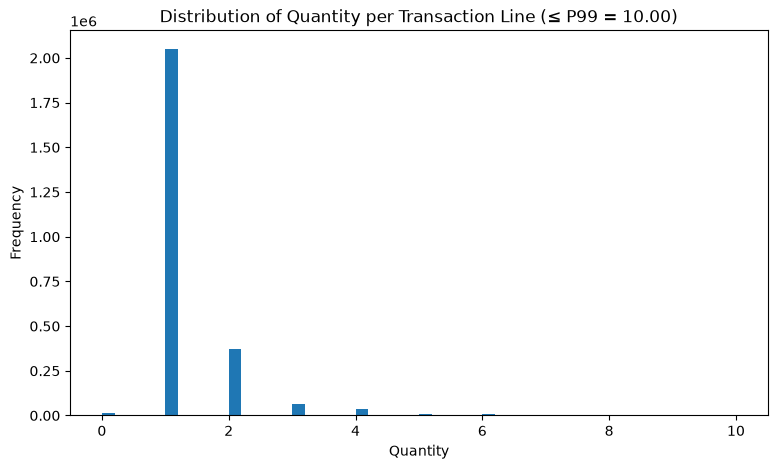

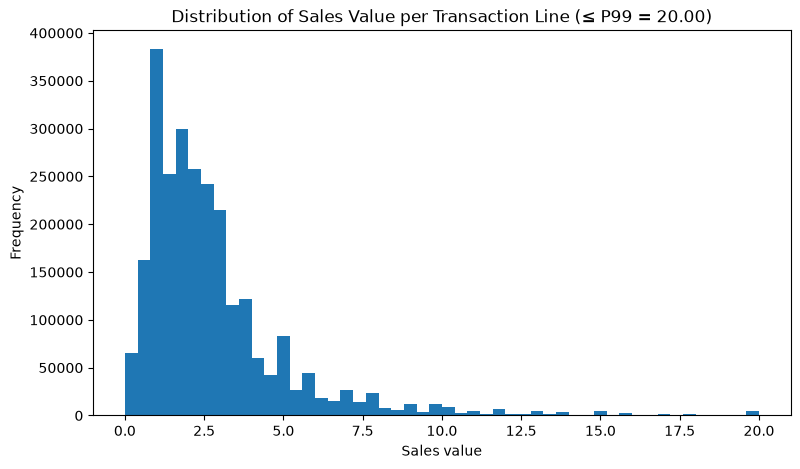

In [30]:
# 9. Distribution of quantity and sales_value (up to P99)

if tx is not None:

    # -----------------------------
    # Quantity - P99
    # -----------------------------
    quantity = tx["quantity"].dropna()
    quantity_p99 = quantity.quantile(0.99)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(
        quantity[quantity <= quantity_p99],
        bins=50
    )

    ax.set_title(
        f"Distribution of Quantity per Transaction Line (≤ P99 = {quantity_p99:.2f})"
    )
    ax.set_xlabel("Quantity")
    ax.set_ylabel("Frequency")

    plt.show()


    # -----------------------------
    # Sales Value - P99
    # -----------------------------
    sales = tx["sales_value"].dropna()
    sales_p99 = sales.quantile(0.99)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.hist(
        sales[sales <= sales_p99],
        bins=50
    )

    ax.set_title(
        f"Distribution of Sales Value per Transaction Line (≤ P99 = {sales_p99:.2f})"
    )
    ax.set_xlabel("Sales value")
    ax.set_ylabel("Frequency")

    plt.show()

## 3. Discount EDA

The User Guide defines:

- `retail_disc`: discount from the retailer's loyalty card programme;
- `coupon_disc`: discount due to a manufacturer coupon;
- `coupon_match_disc`: discount due to the retailer's match of a manufacturer coupon.

The notebook reports them separately because they represent different promotional mechanisms.


In [31]:
# 10. Discount distributions and incidence

discount_cols = ["retail_disc", "coupon_disc", "coupon_match_disc"]

if tx is not None:
    discount_summary = []

    for c in discount_cols:
        s = tx[c].fillna(0)
        discount_summary.append({
            "discount": c,
            "rows_with_nonzero": int((s != 0).sum()),
            "share_nonzero_pct": float((s != 0).mean() * 100),
            "sum": float(s.sum()),
            "mean": float(s.mean()),
            "median": float(s.median()),
            "min": float(s.min()),
            "max": float(s.max()),
        })

    discount_summary = pd.DataFrame(discount_summary)
    display(discount_summary)


,discount,rows_with_nonzero,share_nonzero_pct,sum,mean,median,min,max
0,retail_disc,1303062,50.200,"-1,398,334.840",-0.539,-0.010,-180.000,3.990
1,coupon_disc,36422,1.403,"-42,611.540",-0.016,0.000,-55.930,0.000
2,coupon_match_disc,17449,0.672,"-7,575.810",-0.003,0.000,-7.700,0.000


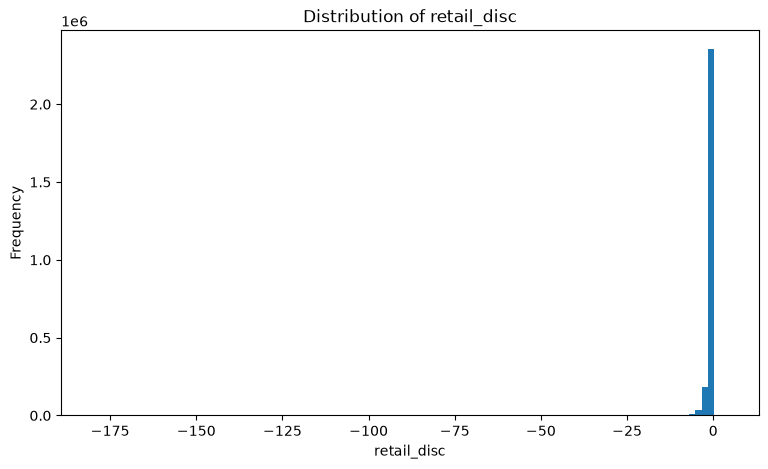

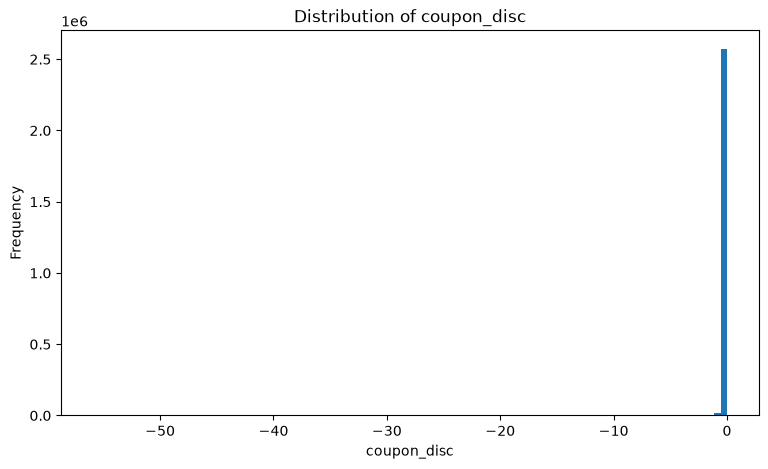

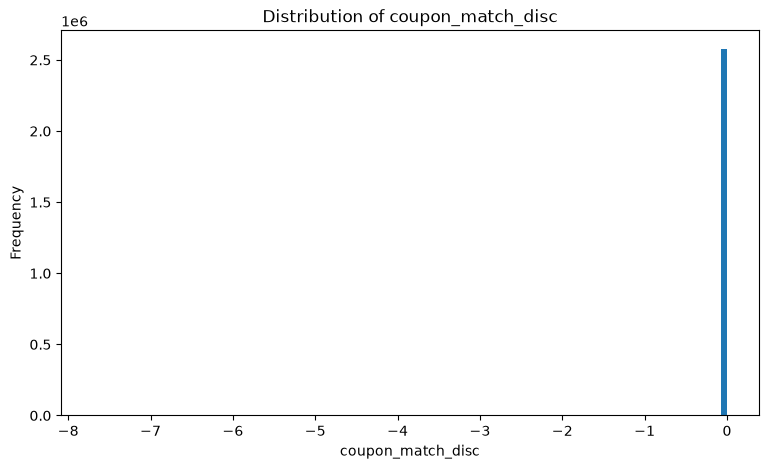

In [32]:
# 11. Discount distributions

if tx is not None:
    for c in discount_cols:
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.hist(tx[c].dropna(), bins=100)
        ax.set_title(f"Distribution of {c}")
        ax.set_xlabel(c)
        ax.set_ylabel("Frequency")
        plt.show()


In [ ]:
# 12. Sales and discount relationship

if tx is not None:
    d = tx[["sales_value"] + discount_cols].copy()

    print("Correlation matrix:")
    display(d.corr(numeric_only=True))

    display(
        tx.groupby("week_no")[["sales_value"] + discount_cols]
          .sum()
          .head(20)
    )


## 4. Basket analysis

`basket_id` identifies a purchase occasion. This section aggregates product-line rows into basket-level metrics.


In [ ]:
# 13. Build basket-level features

if tx is not None:
    basket = (
        tx.groupby(["household_key", "basket_id"], as_index=False)
          .agg(
              day=("day", "min"),
              week_no=("week_no", "min"),
              store_id=("store_id", "first"),
              basket_sales=("sales_value", "sum"),
              basket_quantity=("quantity", "sum"),
              product_lines=("product_id", "count"),
              unique_products=("product_id", "nunique"),
              retail_disc=("retail_disc", "sum"),
              coupon_disc=("coupon_disc", "sum"),
              coupon_match_disc=("coupon_match_disc", "sum"),
          )
    )

    display(basket.head())
    display(basket.describe().T)


In [ ]:
# 14. Basket distributions

if tx is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(basket["basket_sales"], bins=100)
    ax.set_title("Distribution of Basket Sales")
    ax.set_xlabel("Basket sales")
    ax.set_ylabel("Frequency")
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(basket["unique_products"], bins=50)
    ax.set_title("Unique Products per Basket")
    ax.set_xlabel("Unique products")
    ax.set_ylabel("Frequency")
    plt.show()


## 5. Product and category EDA

The `product` table provides the hierarchy:

`DEPARTMENT → COMMODITY_DESC → SUB_COMMODITY_DESC`

This hierarchy is important for the customer × category analysis.


In [ ]:
# 15. Product table inspection

product = tables.get("product")

if product is not None:
    display(product.head())
    print("Unique products:", product["PRODUCT_ID"].nunique() if "PRODUCT_ID" in product else product["product_id"].nunique())
    display(product.isna().mean().mul(100).sort_values(ascending=False).head(20).to_frame("missing_pct"))


In [ ]:
# 16. Join transactions with product hierarchy

if tx is not None and product is not None:
    # Normalize product ID column name if necessary.
    p = product.copy()
    if "PRODUCT_ID" in p.columns and "product_id" not in p.columns:
        p = p.rename(columns={"PRODUCT_ID": "product_id"})

    tx_prod = tx.merge(p, on="product_id", how="left", suffixes=("", "_product"))

    print("Transaction rows before:", len(tx))
    print("Transaction rows after :", len(tx_prod))
    print("Unmatched product IDs  :", tx_prod["DEPARTMENT"].isna().sum() if "DEPARTMENT" in tx_prod else "check column names")

    display(tx_prod.head())


In [ ]:
# 17. Top departments / commodities by sales

if "tx_prod" in globals():
    for col in ["DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]:
        if col in tx_prod.columns:
            result = (
                tx_prod.groupby(col)
                       .agg(
                           sales_value=("sales_value", "sum"),
                           quantity=("quantity", "sum"),
                           households=("household_key", "nunique"),
                           product_lines=("product_id", "size"),
                       )
                       .sort_values("sales_value", ascending=False)
                       .head(20)
            )
            print(f"Top 20 by {col}:")
            display(result)


In [ ]:
# 18. Category sales visualization

if "tx_prod" in globals() and "DEPARTMENT" in tx_prod.columns:
    dept = (
        tx_prod.groupby("DEPARTMENT")["sales_value"]
               .sum()
               .sort_values(ascending=False)
               .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    dept.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top Departments by Sales Value")
    ax.set_xlabel("Sales value")
    ax.set_ylabel("Department")
    plt.show()


## 6. Household/customer EDA

The customer-level view summarizes purchase frequency, spending, basket behavior, product breadth, and discount exposure.

These variables can later become candidate pre-treatment covariates, but they must be constructed using only information available before the treatment period when used in causal modeling.


In [ ]:
# 19. Household-level behavioral profile

if tx is not None:
    household = (
        tx.groupby("household_key")
          .agg(
              total_sales=("sales_value", "sum"),
              total_quantity=("quantity", "sum"),
              baskets=("basket_id", "nunique"),
              product_lines=("product_id", "size"),
              unique_products=("product_id", "nunique"),
              stores=("store_id", "nunique"),
              active_weeks=("week_no", "nunique"),
              retail_discount=("retail_disc", "sum"),
              coupon_discount=("coupon_disc", "sum"),
              coupon_match_discount=("coupon_match_disc", "sum"),
          )
    )

    household["avg_basket_value"] = household["total_sales"] / household["baskets"]
    household["avg_quantity_per_basket"] = household["total_quantity"] / household["baskets"]

    display(household.describe().T)


In [ ]:
# 20. Household spending distribution

if "household" in globals():
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(household["total_sales"], bins=100)
    ax.set_title("Distribution of Household Total Sales")
    ax.set_xlabel("Total sales")
    ax.set_ylabel("Number of households")
    plt.show()


## 7. Customer × Category × Week panel

This is the key analytical grain for the research direction.

The panel aggregates transactions to:

**household × category × week**

It can support later analysis of category affinity, promotion exposure, and future category-level outcomes.


In [ ]:
# 21. Build customer × category × week panel

if "tx_prod" in globals():
    category_col = None
    for candidate in ["COMMODITY_DESC", "SUB_COMMODITY_DESC", "DEPARTMENT"]:
        if candidate in tx_prod.columns:
            category_col = candidate
            break

    if category_col is None:
        print("No product hierarchy column found.")
    else:
        ccw = (
            tx_prod.groupby(["household_key", category_col, "week_no"], as_index=False)
                   .agg(
                       sales_value=("sales_value", "sum"),
                       quantity=("quantity", "sum"),
                       baskets=("basket_id", "nunique"),
                       product_lines=("product_id", "size"),
                       unique_products=("product_id", "nunique"),
                       retail_disc=("retail_disc", "sum"),
                       coupon_disc=("coupon_disc", "sum"),
                       coupon_match_disc=("coupon_match_disc", "sum"),
                   )
        )

        ccw = ccw.rename(columns={category_col: "category"})
        print("Panel shape:", ccw.shape)
        display(ccw.head())


In [ ]:
# 22. Category affinity: top household-category relationships

if "ccw" in globals():
    category_affinity = (
        ccw.groupby(["household_key", "category"], as_index=False)
           .agg(
               sales_value=("sales_value", "sum"),
               quantity=("quantity", "sum"),
               active_weeks=("week_no", "nunique"),
               baskets=("baskets", "sum"),
           )
    )

    display(
        category_affinity.sort_values(
            ["household_key", "sales_value"],
            ascending=[True, False]
        ).head(30)
    )


## 8. Campaign and coupon EDA

The campaign/coupon tables describe marketing exposure and coupon redemption.

A key distinction for later causal work is:

- **received campaign/coupon** ≠ **redeemed coupon** ≠ **observed transaction discount**.

These concepts should not be collapsed into one treatment variable without an explicit definition.


In [ ]:
# 23. Campaign analysis

campaign_table = tables.get("campaign_table")
campaign_desc = tables.get("campaign_desc")

if campaign_table is not None:
    display(campaign_table.head())
    print("Households with campaigns:", campaign_table["HOUSEHOLD_KEY"].nunique() if "HOUSEHOLD_KEY" in campaign_table else "check columns")
    display(campaign_table["DESCRIPTION"].value_counts(dropna=False) if "DESCRIPTION" in campaign_table else pd.Series(dtype=int))

if campaign_desc is not None:
    display(campaign_desc.head())


In [ ]:
# 24. Campaign duration

if campaign_desc is not None:
    cd = campaign_desc.copy()
    if "START_DAY" in cd.columns and "END_DAY" in cd.columns:
        cd["duration_days"] = cd["END_DAY"] - cd["START_DAY"] + 1
        display(cd.describe(include="all").T)
        display(cd.sort_values("duration_days", ascending=False).head(20))


In [ ]:
# 25. Coupon and redemption analysis

coupon = tables.get("coupon")
coupon_redempt = tables.get("coupon_redempt")

if coupon is not None:
    print("Coupon table:", coupon.shape)
    display(coupon.head())
    if "CAMPAIGN" in coupon.columns:
        print("Coupons by campaign:")
        display(coupon.groupby("CAMPAIGN")["COUPON_UPC"].nunique().sort_values(ascending=False).head(20))

if coupon_redempt is not None:
    print("Coupon redemption table:", coupon_redempt.shape)
    display(coupon_redempt.head())
    if "HOUSEHOLD_KEY" in coupon_redempt.columns:
        print("Unique households with redemptions:", coupon_redempt["HOUSEHOLD_KEY"].nunique())
    if "CAMPAIGN" in coupon_redempt.columns:
        print("Redemptions by campaign:")
        display(coupon_redempt["CAMPAIGN"].value_counts().sort_index())


## 9. Causal/promotion exposure EDA

`causal_data` records whether a product was featured in a weekly mailer or in-store display.

This is useful for distinguishing coupon-related behavior from other promotional activity in the store.


In [ ]:
# 26. Causal_data inspection

causal = tables.get("causal_data")

if causal is not None:
    display(causal.head())
    print("Shape:", causal.shape)

    for c in ["display", "mailer"]:
        if c in causal.columns:
            print(f"\n{c} value counts:")
            display(causal[c].value_counts(dropna=False))


In [ ]:
# 27. Join promotion display/mailer exposure to transactions

if tx is not None and causal is not None:
    join_keys = [c for c in ["product_id", "store_id", "week_no"] if c in tx.columns and c in causal.columns]

    if len(join_keys) == 3:
        tx_promo = tx.merge(
            causal,
            on=join_keys,
            how="left",
            suffixes=("", "_causal")
        )

        print("Joined rows:", len(tx_promo))
        print("Display missing:", tx_promo["display"].isna().mean() * 100 if "display" in tx_promo else "n/a")
        print("Mailer missing :", tx_promo["mailer"].isna().mean() * 100 if "mailer" in tx_promo else "n/a")
        display(tx_promo.head())
    else:
        print("Could not construct product × store × week join.")


## 10. Time-series EDA

The dataset covers weeks 1–102 according to the User Guide. This section examines aggregate sales, quantity, discounts, and household activity over time.


In [ ]:
# 28. Weekly sales and activity

if tx is not None:
    weekly = (
        tx.groupby("week_no")
          .agg(
              sales_value=("sales_value", "sum"),
              quantity=("quantity", "sum"),
              households=("household_key", "nunique"),
              baskets=("basket_id", "nunique"),
              product_lines=("product_id", "size"),
              coupon_disc=("coupon_disc", "sum"),
              retail_disc=("retail_disc", "sum"),
              coupon_match_disc=("coupon_match_disc", "sum"),
          )
    )

    display(weekly.head())


In [ ]:
# 29. Weekly sales trend

if "weekly" in globals():
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(weekly.index, weekly["sales_value"])
    ax.set_title("Weekly Sales Value")
    ax.set_xlabel("Week")
    ax.set_ylabel("Sales value")
    plt.show()


## 11. Preliminary promotion-response views

These plots are descriptive only. They should not be interpreted as causal effects.

For a future causal model, define treatment, outcome, time window, and pre-treatment covariates explicitly before estimating uplift/CATE.


In [ ]:
# 30. Descriptive comparison: rows with vs. without coupon discount

if tx is not None:
    tx_tmp = tx.copy()
    tx_tmp["has_coupon_disc"] = tx_tmp["coupon_disc"].fillna(0).ne(0)

    comparison = (
        tx_tmp.groupby("has_coupon_disc")
              .agg(
                  mean_sales=("sales_value", "mean"),
                  median_sales=("sales_value", "median"),
                  mean_quantity=("quantity", "mean"),
                  rows=("sales_value", "size"),
                  households=("household_key", "nunique"),
              )
    )

    display(comparison)


In [ ]:
# 31. Descriptive category-level coupon patterns

if "ccw" in globals():
    category_coupon = (
        ccw.groupby("category")
           .agg(
               sales_value=("sales_value", "sum"),
               quantity=("quantity", "sum"),
               coupon_disc=("coupon_disc", "sum"),
               coupon_match_disc=("coupon_match_disc", "sum"),
               retail_disc=("retail_disc", "sum"),
           )
    )

    category_coupon["coupon_disc_per_sales"] = (
        category_coupon["coupon_disc"].abs()
        / category_coupon["sales_value"].replace(0, np.nan)
    )

    display(category_coupon.sort_values("sales_value", ascending=False).head(30))


## 12. Data quality checks for later Causal ML

Before moving from EDA to causal modeling, check at least:

1. **Temporal ordering** — covariates must be measured before treatment.
2. **Treatment definition** — distinguish campaign receipt, coupon receipt, coupon redemption, and observed transaction discount.
3. **Outcome window** — e.g. future category sales/quantity after treatment.
4. **Customer-category grain** — avoid mixing customer-level and transaction-level observations.
5. **Repeated treatments** — campaigns can occur at multiple times for the same household.
6. **Confounding** — prior purchase behavior may affect both treatment exposure and future outcomes.
7. **Overlap/positivity** — treated and untreated observations need sufficient overlap in relevant covariates.
8. **Missingness** — demographic information is available only for a portion of households.
9. **Promotion interference** — display/mailer activity can occur alongside coupon activity.
10. **Leakage** — do not use post-treatment variables as pre-treatment features.

The notebook intentionally stops at EDA rather than fitting a causal model automatically.


In [ ]:
# 32. Final EDA summary table

summary_rows = []

for name, df in tables.items():
    summary_rows.append({
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_households": (
            df["household_key"].nunique()
            if "household_key" in df.columns
            else df["HOUSEHOLD_KEY"].nunique()
            if "HOUSEHOLD_KEY" in df.columns
            else np.nan
        ),
    })

display(pd.DataFrame(summary_rows))


## 13. Suggested next analytical dataset

For the research project, a natural next step after EDA is to construct a panel such as:

```text
household_key × category × week
```

with:

### Pre-treatment features
- historical category sales;
- historical category quantity;
- purchase frequency;
- recency;
- total household spending;
- category share of spending;
- previous coupon redemption;
- previous discount exposure;
- basket behavior;
- store activity;
- mailer/display exposure.

### Treatment
A precisely defined coupon/promotion exposure, for example:

```text
T = 1  → household is exposed to the target promotion
T = 0  → comparable household-category-week without the target exposure
```

The exact treatment definition must be established from `campaign_table`, `campaign_desc`, `coupon`, `coupon_redempt`, and `transaction_data`.

### Outcome
Potential category-level outcomes include:

```text
future_category_sales
future_category_quantity
future_purchase_indicator
future_category_basket_frequency
```

This panel can then be used as the input layer for subsequent Causal ML/uplift analysis.


## End of notebook

**Scope:** Exploratory Data Analysis and preparation for later causal analysis.

**Interpretation rule:** All relationships shown here are descriptive/observational. They should not be interpreted as causal effects without an appropriate identification strategy.
